In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import os

# Ensure VADER lexicon is available
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/welela/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
news_path = "../data/raw_analyst_ratings.csv"
df_news = pd.read_csv(news_path)

# Standardize columns
df_news['headline'] = df_news['headline'].astype(str)

# Convert dates
df_news['date'] = pd.to_datetime(
    df_news['date'],
    errors='coerce',
    utc=True
).dt.date

# Clean ticker names
df_news['stock'] = df_news['stock'].str.upper().str.strip()

In [3]:
# ---------------------------------------------------
# SENTIMENT ANALYSIS USING VADER
# ---------------------------------------------------
df_news['sentiment'] = df_news['headline'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

# ---------------------------------------------------
# DAILY AVERAGE SENTIMENT
# ---------------------------------------------------
daily_sentiment = (
    df_news
    .groupby(['date', 'stock'])['sentiment']
    .mean()
    .reset_index()
)



AAPL
Pearson Correlation: 1.0000
P-value: 1.0000


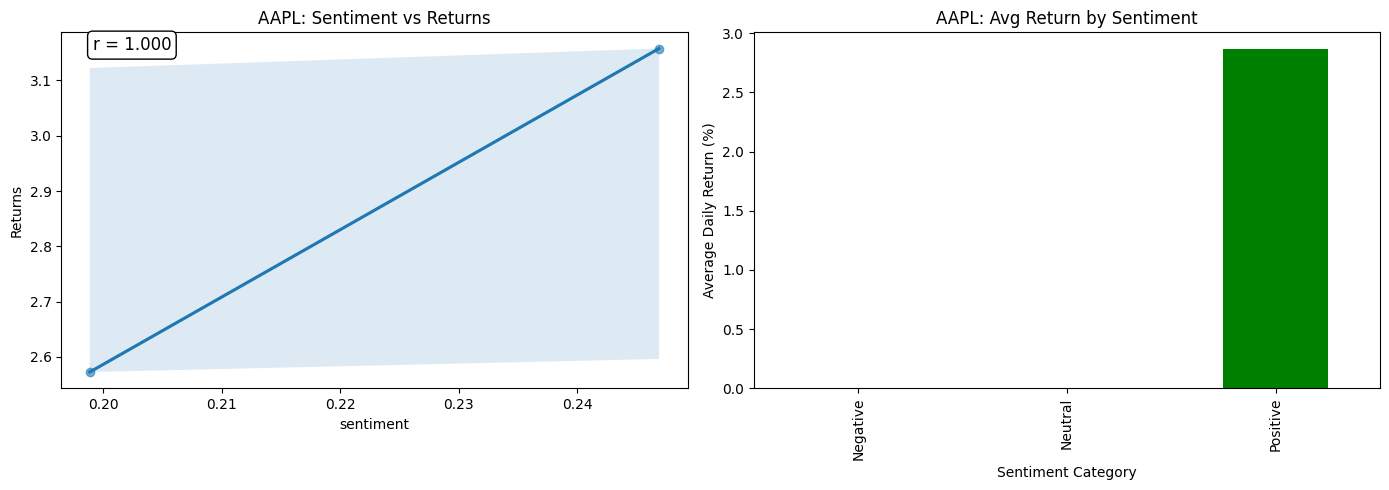


AMZN
Pearson Correlation: -1.0000
P-value: 1.0000


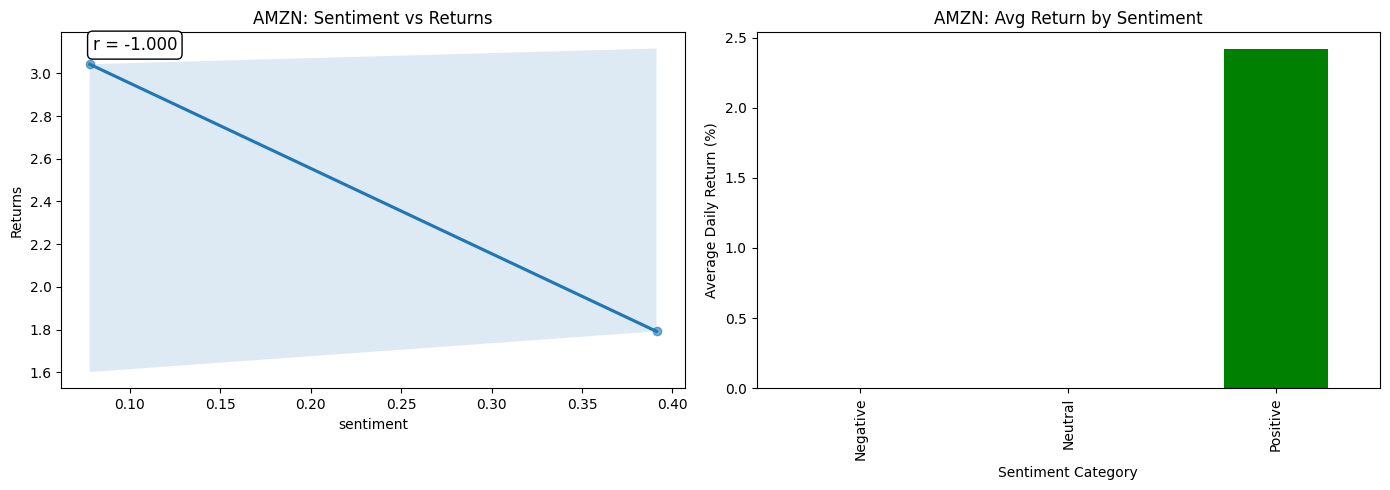


GOOG
Pearson Correlation: -0.2344
P-value: 0.7044


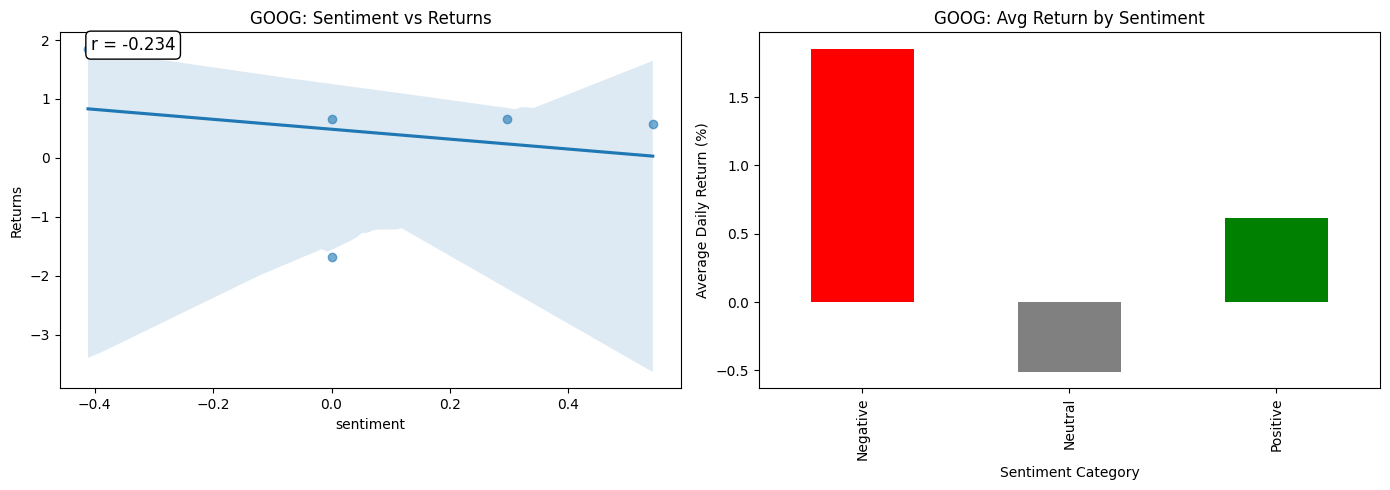


META
Pearson Correlation: -0.9730
P-value: 0.1483


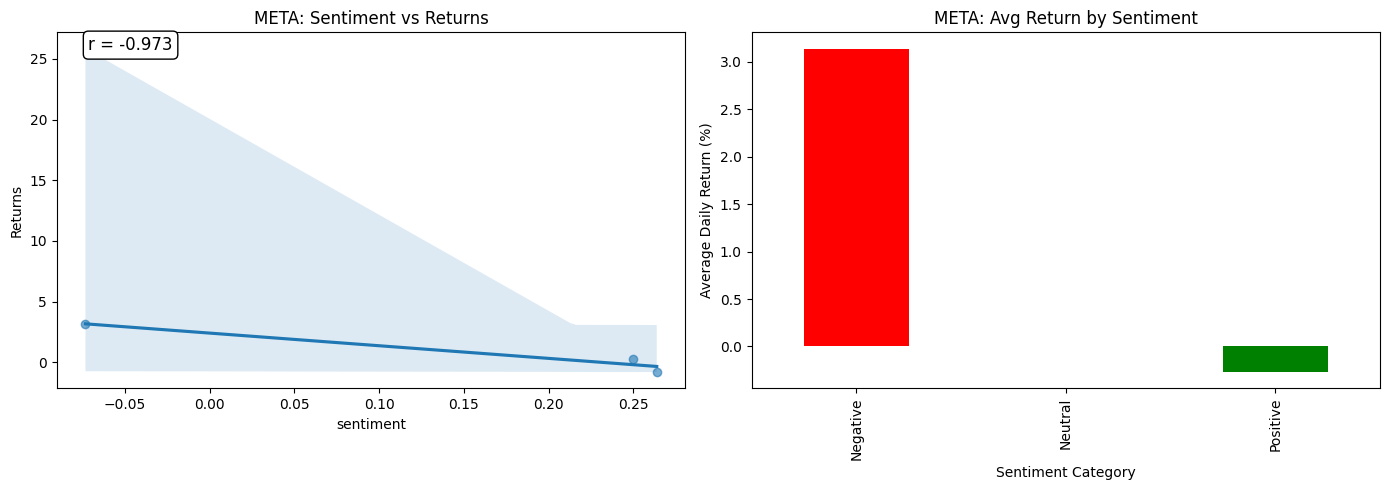


NVDA
Pearson Correlation: 0.3965
P-value: 0.5087


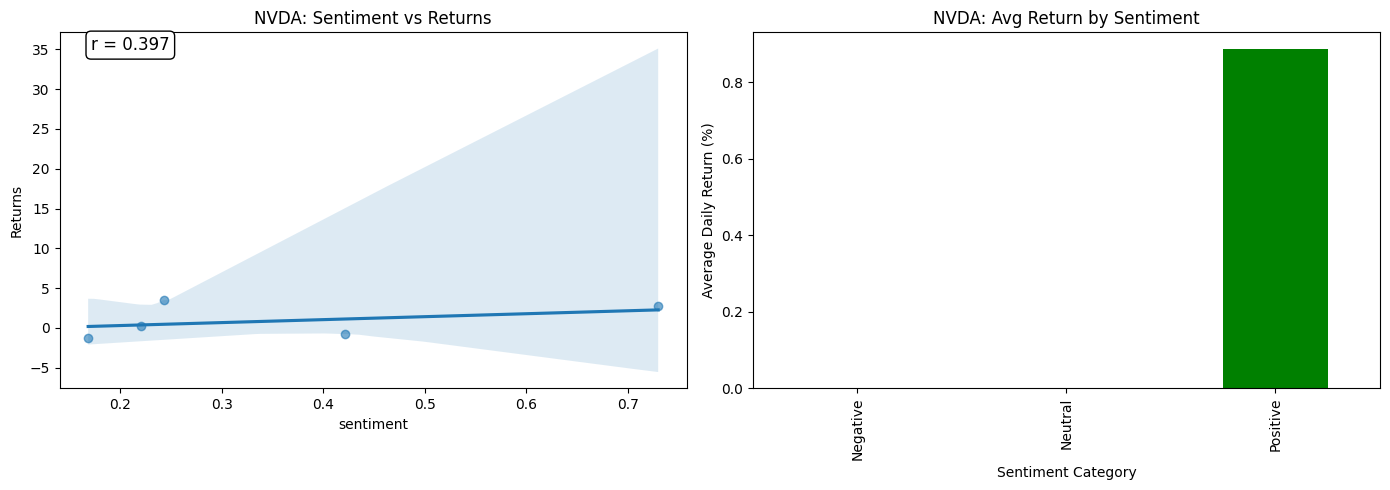

In [6]:
# ---------------------------------------------------
# STOCK TICKERS
# ---------------------------------------------------
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

# Store merged results
all_results = []
# ---------------------------------------------------
# PROCESS EACH STOCK
# ---------------------------------------------------
for ticker in tickers:

    stock_path = f"../data/{ticker}.csv"

    if not os.path.exists(stock_path):
        print(f"{ticker} file not found.")
        continue

    # -----------------------------------------------
    # LOAD STOCK DATA
    # -----------------------------------------------
    df_stock = pd.read_csv(stock_path)

    df_stock['Date'] = pd.to_datetime(
        df_stock['Date'],
        errors='coerce'
    ).dt.date

    # Sort by date
    df_stock = df_stock.sort_values('Date')

    # Daily returns
    df_stock['Returns'] = (
        df_stock['Close'].pct_change() * 100
    )

    # -----------------------------------------------
    # HANDLE META / FB NAME CHANGE
    # -----------------------------------------------
    news_ticker = 'FB' if ticker == 'META' else ticker

    ticker_news = daily_sentiment[
        daily_sentiment['stock'] == news_ticker
    ].copy()

    # -----------------------------------------------
    # ALIGN NEWS TO NEXT TRADING DAY
    # -----------------------------------------------
    trading_days = sorted(df_stock['Date'].unique())

    def get_next_trading_day(news_date):
        for td in trading_days:
            if td >= news_date:
                return td
        return np.nan

    ticker_news['aligned_date'] = ticker_news['date'].apply(
        get_next_trading_day
    )

    ticker_news.dropna(subset=['aligned_date'], inplace=True)

    # -----------------------------------------------
    # MERGE NEWS + RETURNS
    # -----------------------------------------------
    merged = pd.merge(
        ticker_news,
        df_stock[['Date', 'Returns']],
        left_on='aligned_date',
        right_on='Date',
        how='inner'
    )

    merged.dropna(subset=['Returns'], inplace=True)

    if merged.empty:
        continue

    # Add ticker column
    merged['Ticker'] = ticker

    # Store results
    all_results.append(merged)

    # -----------------------------------------------
    # PEARSON CORRELATION
    # -----------------------------------------------
    corr, p_value = pearsonr(
        merged['sentiment'],
        merged['Returns']
    )

    print(f"\n{ticker}")
    print(f"Pearson Correlation: {corr:.4f}")
    print(f"P-value: {p_value:.4f}")

    # -----------------------------------------------
    # SENTIMENT CATEGORIES
    # -----------------------------------------------
    merged['Category'] = merged['sentiment'].apply(
        lambda x:
            'Positive' if x > 0.05
            else ('Negative' if x < -0.05
                  else 'Neutral')
    )

    # -----------------------------------------------
    # VISUALIZATIONS
    # -----------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    # Scatter plot
    sns.regplot(
        data=merged,
        x='sentiment',
        y='Returns',
        ax=ax1,
        scatter_kws={'alpha': 0.6}
    )

    ax1.set_title(f"{ticker}: Sentiment vs Returns")

    ax1.annotate(
        f"r = {corr:.3f}",
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=12,
        bbox=dict(boxstyle="round", fc="white")
    )

    # Bar chart
    avg_returns = (
        merged.groupby('Category')['Returns']
        .mean()
        .reindex(['Negative', 'Neutral', 'Positive'])
    )

    avg_returns.plot(
        kind='bar',
        ax=ax2,
        color=['red', 'gray', 'green']
    )

    ax2.set_title(f"{ticker}: Avg Return by Sentiment")
    ax2.set_ylabel("Average Daily Return (%)")
    ax2.set_xlabel("Sentiment Category")

    plt.tight_layout()
    plt.show()


In [7]:
# ---------------------------------------------------
# FINAL MARKET-WIDE ANALYSIS
# ---------------------------------------------------
if all_results:

    final_df = pd.concat(all_results)

    overall_corr, overall_p = pearsonr(
        final_df['sentiment'],
        final_df['Returns']
    )

    print("\n============================")
    print("MARKET-WIDE ANALYSIS")
    print("============================")

    print(f"Overall Correlation: {overall_corr:.4f}")
    print(f"Overall P-value: {overall_p:.4f}")


MARKET-WIDE ANALYSIS
Overall Correlation: -0.0239
Overall P-value: 0.9274


The analysis examined the relationship between financial news sentiment and daily stock returns for major technology companies including AAPL, AMZN, GOOG, META, and NVDA. News headlines were analyzed using the VADER sentiment analysis tool, which generated compound sentiment scores ranging from negative to positive values. These sentiment scores were aggregated by trading day and compared with daily percentage stock returns using the Pearson correlation coefficient. The scatter plots and calculated correlation values showed whether positive or negative news sentiment was associated with corresponding stock price movements. In general, a positive correlation indicates that optimistic news sentiment tends to align with positive stock returns, while a negative correlation suggests that negative news sentiment is associated with declining stock prices. However, the strength of the correlations may vary across companies and could be weak in some cases, indicating that sentiment alone is not a strong predictor of daily market behavior.

Several limitations should be considered when interpreting the results. First, stock markets may not react immediately to news, meaning that lag effects could weaken the observed relationship between sentiment and returns. Second, the analysis only considered news headlines rather than full article content, which may omit important contextual information. Additionally, external factors such as macroeconomic events, interest rates, earnings announcements, and broader market trends can significantly influence stock prices independently of news sentiment. Finally, while VADER performs well on short text, it is a lexicon-based model and may not fully capture complex financial language, sarcasm, or nuanced market sentiment. Despite these limitations, the analysis provides useful insight into how financial news sentiment may relate to short-term stock market movements.
